Capital Analyst — Evidence 2

## 0. Libraries

In [1]:
%pip install yfinance statsmodels openpyxl -q


[notice] A new release of pip is available: 25.1.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
import yfinance as yf
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt

We install the libraries from inside the notebook with `%pip`

## 1. Investment Universe

In [3]:
tickers_mx = ["WALMEX.MX", "AC.MX", "FEMSAUBD.MX", "BIMBOA.MX", "ALSEA.MX"]
tickers_us = ["AAPL", "MSFT", "AMZN", "KO", "PG"]
tickers = tickers_mx + tickers_us

start_date = "2021-08-31"
end_date = "2026-08-31"

raw_data = yf.download(tickers, start=start_date, end=end_date, auto_adjust=True)["Close"]
raw_data = raw_data[tickers]

print(raw_data.shape)
raw_data.head()

[*********************100%***********************]  10 of 10 completed

(1293, 10)


Ticker,WALMEX.MX,AC.MX,FEMSAUBD.MX,BIMBOA.MX,ALSEA.MX,AAPL,MSFT,AMZN,KO,PG
Date,,,,,,,,,,
2021-08-31,62.062904,104.969269,142.697906,47.127102,37.502819,148.090591,289.722443,173.539505,48.567825,125.225525
2021-09-01,61.915268,103.679161,138.168961,46.969456,38.362537,148.753845,289.674438,173.949997,48.895584,126.500702
2021-09-02,60.516987,101.131409,139.743896,46.709801,40.129734,149.865768,289.021851,173.156006,48.964592,126.597481
2021-09-03,60.482246,100.417374,138.748352,45.819561,39.126732,150.499802,289.012299,173.902496,48.930088,126.685440
2021-09-06,61.316006,100.912346,141.229065,46.338863,40.081974,NaN,NaN,NaN,NaN,NaN


We use the same 10 stocks from Deliverable 1, downloaded with the yfinance API and
with adjusted closing prices, because some of these stocks pay dividends.

In [4]:
fondo = raw_data.ffill().dropna()
fondo.index = pd.to_datetime(fondo.index)

print("Days of prices per stock:")
print(fondo.count())
print()
print("Final shape:", fondo.shape)

Days of prices per stock:
Ticker
WALMEX.MX      1293
AC.MX          1293
FEMSAUBD.MX    1293
BIMBOA.MX      1293
ALSEA.MX       1293
AAPL           1293
MSFT           1293
AMZN           1293
KO             1293
PG             1293
dtype: int64

Final shape: (1293, 10)


With `.ffill()` we replace each missing value with the last known price.
With `.dropna()` we remove the rows that are still empty.

We print the count of days per stock to check it again. 

In [5]:
returns = fondo.pct_change().dropna()

fondo_return = returns.mean(axis=1)
fondo_return.name = "Fondo_Return"
fondo_index = (1 + fondo_return).cumprod()

print(returns.shape)
returns.head()

(1292, 10)


Ticker,WALMEX.MX,AC.MX,FEMSAUBD.MX,BIMBOA.MX,ALSEA.MX,AAPL,MSFT,AMZN,KO,PG
Date,,,,,,,,,,
2021-09-01,-0.002379,-0.012290,-0.031738,-0.003345,0.022924,0.004479,-0.000166,0.002365,0.006748,0.010183
2021-09-02,-0.022584,-0.024573,0.011399,-0.005528,0.046066,0.007475,-0.002253,-0.004564,0.001411,0.000765
2021-09-03,-0.000574,-0.007060,-0.007124,-0.019059,-0.024994,0.004231,-0.000033,0.004311,-0.000705,0.000695
2021-09-06,0.013785,0.004929,0.017879,0.011334,0.024414,0.000000,0.000000,0.000000,0.000000,0.000000
2021-09-07,-0.002833,0.011819,-0.022130,-0.010406,-0.006196,0.015489,-0.003188,0.008982,-0.018685,-0.003749


With `.pct_change()` we turn the prices into daily returns, and with `.mean(axis=1)`
we get the daily return of the fund assuming all 10 stocks have equal weight.

In [6]:
correlation = returns.corr()
print(correlation.round(2))

Ticker       WALMEX.MX  AC.MX  FEMSAUBD.MX  BIMBOA.MX  ALSEA.MX  AAPL  MSFT  \
Ticker                                                                        
WALMEX.MX         1.00   0.21         0.19       0.20      0.17  0.11  0.09   
AC.MX             0.21   1.00         0.26       0.25      0.15  0.07  0.05   
FEMSAUBD.MX       0.19   0.26         1.00       0.22      0.18  0.12  0.10   
BIMBOA.MX         0.20   0.25         0.22       1.00      0.18  0.13  0.13   
ALSEA.MX          0.17   0.15         0.18       0.18      1.00  0.16  0.15   
AAPL              0.11   0.07         0.12       0.13      0.16  1.00  0.53   
MSFT              0.09   0.05         0.10       0.13      0.15  0.53  1.00   
AMZN              0.12   0.06         0.09       0.11      0.16  0.49  0.61   
KO                0.10   0.10         0.15       0.05      0.10  0.25  0.13   
PG                0.10   0.10         0.11       0.09      0.04  0.25  0.14   

Ticker       AMZN    KO    PG  
Ticker             

In [7]:
# Average correlation inside Mexico, inside the US, and between the two markets.
# We take out the diagonal because a stock with itself is always 1.
corr_mx = correlation.loc[tickers_mx, tickers_mx]
corr_us = correlation.loc[tickers_us, tickers_us]
corr_mx_us = correlation.loc[tickers_mx, tickers_us]

avg_mx = (corr_mx.values.sum() - 5) / (5 * 5 - 5)
avg_us = (corr_us.values.sum() - 5) / (5 * 5 - 5)
avg_between = corr_mx_us.values.mean()

print(f"Average correlation between Mexican stocks: {avg_mx:.3f}")
print(f"Average correlation between US stocks:      {avg_us:.3f}")
print(f"Average correlation Mexico vs US:           {avg_between:.3f}")

Average correlation between Mexican stocks: 0.200
Average correlation between US stocks:      0.321
Average correlation Mexico vs US:           0.104


Coorelations helps us in the part of decreasing a risk by diversification.

In [8]:
# How much volatility we save by combining the 10 stocks
stock_volatility = returns.std() * np.sqrt(252)
average_volatility = stock_volatility.mean()
portfolio_volatility = fondo_return.std() * np.sqrt(252)

reduction = 1 - portfolio_volatility / average_volatility

print(stock_volatility.sort_values(ascending=False).round(4))
print()
print(f"Average volatility of the 10 stocks separately: {average_volatility:.2%}")
print(f"Volatility of the portfolio together:          {portfolio_volatility:.2%}")
print(f"Reduction from diversifying:                   {reduction:.2%}")

Ticker
AMZN           0.3589
BIMBOA.MX      0.3107
ALSEA.MX       0.2957
MSFT           0.2773
AAPL           0.2761
WALMEX.MX      0.2502
FEMSAUBD.MX    0.2304
AC.MX          0.2270
PG             0.1785
KO             0.1644
dtype: float64

Average volatility of the 10 stocks separately: 25.69%
Volatility of the portfolio together:          13.23%
Reduction from diversifying:                   48.52%


The average volatility of the stocks themselves is higher than the volatility of the portfolio.

## 2. Risk Metrics

calculate the four metrics.

In [9]:
benchmarks = ["^GSPC", "^MXX", "^TNX"]   # S&P 500, IPC of Mexico, 10-year Treasury
macro_data = yf.download(benchmarks, start=start_date, end=end_date, auto_adjust=True)["Close"]
macro_data = macro_data.ffill().dropna()

sp500_return = macro_data["^GSPC"].pct_change().dropna()
ipc_return = macro_data["^MXX"].pct_change().dropna()

# The Treasury is already a rate in percent, so we only take the average and divide by 100
risk_free = macro_data["^TNX"].mean() / 100

print(f"Average 10-year Treasury rate: {risk_free:.2%}")

[*********************100%***********************]  3 of 3 completed

Average 10-year Treasury rate: 3.76%


We need the benchmarks for two things: the Beta is measured against the market, and the
Sharpe ratio needs a risk free rate. We use the S&P 500 for the US stocks, the IPC for
the Mexican ones, and the 10-year Treasury as the risk free rate.

In [10]:
# We go stock by stock and calculate every metric
rows = []

for ticker in tickers:
    r = returns[ticker]

    if ticker in tickers_mx:
        market = ipc_return
        market_name = "IPC"
    else:
        market = sp500_return
        market_name = "S&P 500"

    annual_return = (1 + r.mean()) ** 252 - 1
    annual_vol = r.std() * np.sqrt(252)
    beta = r.cov(market) / market.var()
    sharpe = (annual_return - risk_free) / annual_vol

    var_95 = np.percentile(r, 5)                 # historical VaR, worst 5% of days
    var_normal = r.mean() - 1.645 * r.std()      # parametric VaR, assuming normal
    cvar_95 = r[r <= var_95].mean()              # average loss when VaR is passed

    price_index = (1 + r).cumprod()
    drawdown = price_index / price_index.cummax() - 1
    max_drawdown = drawdown.min()

    rows.append({
        "Stock": ticker,
        "Market": market_name,
        "Ann. Return": annual_return,
        "Ann. Volatility": annual_vol,
        "Beta": beta,
        "Sharpe": sharpe,
        "VaR 95% hist.": var_95,
        "VaR 95% normal": var_normal,
        "CVaR 95%": cvar_95,
        "Max Drawdown": max_drawdown,
    })

risk_metrics = pd.DataFrame(rows).set_index("Stock")
risk_metrics.round(4)

,Market,Ann. Return,Ann. Volatility,Beta,Sharpe,VaR 95% hist.,VaR 95% normal,CVaR 95%,Max Drawdown
Stock,,,,,,,,,
WALMEX.MX,IPC,-0.0187,0.2502,0.8321,-0.2250,-0.0243,-0.0260,-0.0333,-0.3602
AC.MX,IPC,0.1570,0.2270,0.6217,0.5258,-0.0220,-0.0229,-0.0294,-0.1710
FEMSAUBD.MX,IPC,0.1020,0.2304,0.7199,0.2795,-0.0212,-0.0235,-0.0311,-0.3160
BIMBOA.MX,IPC,0.0956,0.3107,0.8779,0.1868,-0.0308,-0.0318,-0.0410,-0.4911
ALSEA.MX,IPC,0.0635,0.2957,0.7652,0.0876,-0.0287,-0.0304,-0.0406,-0.5115
AAPL,S&P 500,0.2069,0.2761,1.1883,0.6130,-0.0271,-0.0279,-0.0395,-0.3336
MSFT,S&P 500,0.1616,0.2773,1.1471,0.4472,-0.0269,-0.0281,-0.0379,-0.3715
AMZN,S&P 500,0.1591,0.3589,1.5068,0.3386,-0.0330,-0.0366,-0.0495,-0.5573
KO,S&P 500,0.1423,0.1644,0.2612,0.6369,-0.0155,-0.0165,-0.0220,-0.1727


What each metric is, in the order we calculated them:

- **Annualized volatility** It measures how much the price increase or decrease. 
- **Beta** is the covariance of the stock with its market divided by the variance of the
  market.
- **Sharpe ratio** is the return above the risk free rate divided by the volatility. 
- **VaR 95%** is the loss that is only passed on 5% of the days. 
- **CVaR** is the average loss.
- **Max drawdown** For a client like George it is the loss he would have had to live through
  without selling.

In [11]:
# The same metrics but for the whole portfolio.
# For the Beta we use a 50/50 mix of both markets, because the fund is half and half.
market_blend = (sp500_return + ipc_return).dropna() / 2

fondo_annual_return = (1 + fondo_return.mean()) ** 252 - 1
fondo_annual_vol = fondo_return.std() * np.sqrt(252)
fondo_beta = fondo_return.cov(market_blend) / market_blend.var()
fondo_sharpe = (fondo_annual_return - risk_free) / fondo_annual_vol

fondo_var = np.percentile(fondo_return, 5)
fondo_var_normal = fondo_return.mean() - 1.645 * fondo_return.std()
fondo_cvar = fondo_return[fondo_return <= fondo_var].mean()

fondo_drawdown = fondo_index / fondo_index.cummax() - 1
fondo_max_drawdown = fondo_drawdown.min()

print(f"Annualized return:   {fondo_annual_return:.2%}")
print(f"Annualized vol:      {fondo_annual_vol:.2%}")
print(f"Beta vs 50/50 mix:   {fondo_beta:.3f}")
print(f"Sharpe ratio:        {fondo_sharpe:.3f}")
print(f"VaR 95% historical:  {fondo_var:.2%}  daily")
print(f"VaR 95% normal:      {fondo_var_normal:.2%}  daily")
print(f"CVaR 95%:            {fondo_cvar:.2%}  daily")
print(f"Max drawdown:        {fondo_max_drawdown:.2%}")

Annualized return:   10.94%
Annualized vol:      13.23%
Beta vs 50/50 mix:   0.796
Sharpe ratio:        0.543
VaR 95% historical:  -1.26%  daily
VaR 95% normal:      -1.33%  daily
CVaR 95%:            -1.79%  daily
Max drawdown:        -15.69%


The historical one uses the days that really happened and the parametric one assumes a
normal distribution.

## 3. Goodness of Fit of the Model

We build the same variables from Deliverable 1 and we compare three models to see which
one really explains the returns of the fund.

In [12]:
# Technical variables, all shifted one day so we only use information from the past
tech = pd.DataFrame(index=fondo_return.index)
tech["Lag_Return"] = fondo_return.shift(1)
tech["SMA_50"] = fondo_index.rolling(window=50).mean().shift(1)
tech["SMA_200"] = fondo_index.rolling(window=200).mean().shift(1)

delta = fondo_index.diff()
gain = delta.where(delta > 0, 0.0)
loss = -delta.where(delta < 0, 0.0)
rs = gain.rolling(14).mean() / loss.rolling(14).mean()
tech["RSI_14"] = (100 - (100 / (1 + rs))).shift(1)

tech.tail()

,Lag_Return,SMA_50,SMA_200,RSI_14
Date,,,,
2026-08-24,0.005293,1.590013,1.564452,34.368898
2026-08-25,0.009048,1.590510,1.564830,40.246843
2026-08-26,0.005511,1.591126,1.565351,48.005964
2026-08-27,-0.001267,1.592012,1.565869,45.764691
2026-08-28,-0.006869,1.592836,1.566369,38.967624


In [13]:
# Macro variables, also shifted one day
macro = pd.DataFrame(index=macro_data.index)
macro["SP500_lag1"] = macro_data["^GSPC"].pct_change().shift(1)
macro["IPC_lag1"] = macro_data["^MXX"].pct_change().shift(1)
macro["Treasury_lag1"] = macro_data["^TNX"].diff().shift(1)

model_data = pd.concat([fondo_return, tech, macro], axis=1).dropna()

print("Rows we can use for the models:", len(model_data))
model_data.head()

Rows we can use for the models: 1092


,Fondo_Return,Lag_Return,SMA_50,SMA_200,RSI_14,SP500_lag1,IPC_lag1,Treasury_lag1
Date,,,,,,,,
2022-06-09,-0.014594,-0.002136,1.040299,1.041474,70.001436,-0.010794,-0.006380,0.057
2022-06-10,-0.026106,-0.014594,1.038114,1.041468,58.650134,-0.023799,-0.010620,0.015
2022-06-13,-0.018568,-0.026106,1.035361,1.041328,41.596273,-0.029110,-0.016610,0.112
2022-06-14,-0.010321,-0.018568,1.032109,1.041124,37.661765,-0.038768,-0.000541,0.210
2022-06-15,0.019167,-0.010321,1.028616,1.040834,31.211212,-0.003774,-0.005797,0.117


Everything is shifted one day with `.shift(1)` because if we used the same day's data
we would be predicting today with today's information, which in real life we would not be able to
have.

We join everything and use `.dropna()` once, so the three models are estimated on exactly
the same rows.

In [14]:
# Model 1: only technical variables
X1 = sm.add_constant(model_data[["Lag_Return", "SMA_50", "SMA_200", "RSI_14"]])
model_1 = sm.OLS(model_data["Fondo_Return"], X1).fit()

# Model 2: only macro variables
X2 = sm.add_constant(model_data[["SP500_lag1", "IPC_lag1", "Treasury_lag1"]])
model_2 = sm.OLS(model_data["Fondo_Return"], X2).fit()

# Model 3: everything together
X3 = sm.add_constant(model_data[["Lag_Return", "SMA_50", "SMA_200", "RSI_14",
                                 "SP500_lag1", "IPC_lag1", "Treasury_lag1"]])
model_3 = sm.OLS(model_data["Fondo_Return"], X3).fit()

comparison = pd.DataFrame({
    "Technical": [model_1.rsquared, model_1.rsquared_adj, model_1.aic, model_1.bic, len(X1.columns) - 1],
    "Macro": [model_2.rsquared, model_2.rsquared_adj, model_2.aic, model_2.bic, len(X2.columns) - 1],
    "Full": [model_3.rsquared, model_3.rsquared_adj, model_3.aic, model_3.bic, len(X3.columns) - 1],
}, index=["R2", "Adjusted R2", "AIC", "BIC", "Variables"])

comparison.round(4)

,Technical,Macro,Full
R2,0.0043,0.0025,0.0070
Adjusted R2,0.0006,-0.0003,0.0006
AIC,-7429.5835,-7429.5701,-7426.5241
BIC,-7404.6047,-7409.5870,-7386.5579
Variables,4.0000,3.0000,7.0000


In [15]:
print(model_3.summary())

                            OLS Regression Results                            
Dep. Variable:           Fondo_Return   R-squared:                       0.007
Model:                            OLS   Adj. R-squared:                  0.001
Method:                 Least Squares   F-statistic:                     1.088
Date:                Thu, 10 Sep 2026   Prob (F-statistic):              0.369
Time:                        17:24:37   Log-Likelihood:                 3721.3
No. Observations:                1092   AIC:                            -7427.
Df Residuals:                    1084   BIC:                            -7387.
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const             0.0037      0.002      1.782

How to read the three numbers:

- **R2** is the part of the movement of the fund that the model explains. 
- **AIC** and **BIC**  The lower the AIC or BIC, the better the model. 
- The **adjusted R2** does the same function as AIC and BIC but on the R2 scale.

## 4. Simulation and Backtesting

The simulation asks what could happen in the future, the backtest asks what would have happened in the past.

### 4.1 Monte Carlo simulation

In [16]:
np.random.seed(42)

initial_capital = 1000000
years = 10
days = years * 252
n_simulations = 2000

# We take the real daily returns of the fund and draw from them at random, with
# replacement. Each column of the matrix is one possible future of 10 years.
observed_returns = fondo_return.values
simulated = np.random.choice(observed_returns, size=(days, n_simulations), replace=True)

paths = initial_capital * np.cumprod(1 + simulated, axis=0)
final_values = paths[-1]

p5 = np.percentile(final_values, 5)
p25 = np.percentile(final_values, 25)
p50 = np.percentile(final_values, 50)
p75 = np.percentile(final_values, 75)
p95 = np.percentile(final_values, 95)

print(f"Starting capital: ${initial_capital:,.0f}   Horizon: {years} years   Scenarios: {n_simulations:,}")
print()
print(f"Worst 5%   (pessimistic): ${p5:,.0f}")
print(f"Percentile 25:            ${p25:,.0f}")
print(f"Median:                   ${p50:,.0f}")
print(f"Percentile 75:            ${p75:,.0f}")
print(f"Best 5%    (optimistic):  ${p95:,.0f}")
print()
print(f"Probability of ending with less than what was invested: {(final_values < initial_capital).mean():.1%}")
print(f"Probability of at least doubling the money:             {(final_values > 2 * initial_capital).mean():.1%}")

Starting capital: $1,000,000   Horizon: 10 years   Scenarios: 2,000

Worst 5%   (pessimistic): $1,328,104
Percentile 25:            $1,940,505
Median:                   $2,576,403
Percentile 75:            $3,405,903
Best 5%    (optimistic):  $4,977,964

Probability of ending with less than what was invested: 1.1%
Probability of at least doubling the money:             73.0%


In conclusion The result is not one number, it is a range. That is the honest way to present it to the
client: with this fund and this horizon, this is the range of where he could end up, and
this is how likely each part of the range is.

### 4.2 Backtesting the strategy

In [17]:
# Strategy: we are invested while the 50-day average is above the 200-day average,
# and we go to cash when it is below.
sma_50 = fondo_index.rolling(50).mean()
sma_200 = fondo_index.rolling(200).mean()

signal = (sma_50 > sma_200).astype(int)
signal = signal.shift(1)          # we trade with yesterday's signal, not today's

backtest = pd.DataFrame({"return": fondo_return, "signal": signal}).dropna()

# Transaction cost of 0.10% every time we enter or leave the market
cost = 0.001
trades = backtest["signal"].diff().abs().fillna(0)
backtest["strategy"] = backtest["signal"] * backtest["return"] - trades * cost

backtest["buy_and_hold_value"] = (1 + backtest["return"]).cumprod()
backtest["strategy_value"] = (1 + backtest["strategy"]).cumprod()

print("Number of trades:", int(trades.sum()))
backtest.tail()

Number of trades: 9


,return,signal,strategy,buy_and_hold_value,strategy_value
Date,,,,,
2026-08-24,0.009048,1.0,0.009048,1.619015,1.353205
2026-08-25,0.005511,1.0,0.005511,1.627938,1.360664
2026-08-26,-0.001267,1.0,-0.001267,1.625875,1.358939
2026-08-27,-0.006869,1.0,-0.006869,1.614707,1.349605
2026-08-28,0.008886,1.0,0.008886,1.629055,1.361597


 We charge a cost every time the position changes.

In [18]:
# We compare the strategy against simply buying and holding
results = []

for name, r in [("Buy and hold", backtest["return"]), ("SMA 50/200 strategy", backtest["strategy"])]:
    total_return = (1 + r).prod() - 1
    annual_return = (1 + r.mean()) ** 252 - 1
    annual_vol = r.std() * np.sqrt(252)
    sharpe = (annual_return - risk_free) / annual_vol
    value = (1 + r).cumprod()
    max_dd = (value / value.cummax() - 1).min()
    var = np.percentile(r, 5)

    results.append({
        "Strategy": name,
        "Total Return": total_return,
        "Ann. Return": annual_return,
        "Ann. Volatility": annual_vol,
        "Sharpe": sharpe,
        "Max Drawdown": max_dd,
        "VaR 95%": var,
    })

comparison_bt = pd.DataFrame(results).set_index("Strategy")

# Days with a positive return. For the strategy we only count the days it was invested,
# because the days in cash are zero and would make the percentage look worse than it is.
invested = backtest["signal"] == 1
pct_positive_bh = (backtest["return"] > 0).mean()
pct_positive_st = (backtest.loc[invested, "strategy"] > 0).mean()

comparison_bt["% Positive Days"] = [pct_positive_bh, pct_positive_st]
comparison_bt["% Time in Market"] = [1.0, invested.mean()]

comparison_bt.round(4)

,Total Return,Ann. Return,Ann. Volatility,Sharpe,Max Drawdown,VaR 95%,% Positive Days,% Time in Market
Strategy,,,,,,,,
Buy and hold,0.6291,0.1096,0.1323,0.5440,-0.1569,-0.0126,0.5290,1.0000
SMA 50/200 strategy,0.3616,0.0667,0.0927,0.3136,-0.1523,-0.0095,0.5263,0.6638


We separate the percentage of positive days from the percentage of time in the market on
purpose.

## 5. Investment Strategy and Transaction Script

###  Guidelines

1. **Base allocation.** Equal weight in the 10 stocks, 10% each, half Mexico and half
   the US. Equal weight because we do not have a reason to think one of the 10 is going
   to beat the others, and concentrating would be taking a bet we cannot justify.
2. **Trend filter.** We stay invested while the 50-day average is above the 200-day
   average. When it crosses below, we move to cash. This is what protects the drawdown,
   which is the number that makes a client sell at the worst moment.
3. **Risk filter per stock.** Any stock with a Beta above 1.5 gets its weight cut in
   half, and the difference goes to the stocks with the lowest volatility. The client
   said moderate risk, so we do not carry positions that amplify the market that much.
4. **Rebalancing.** Quarterly, and only if a weight moved more than 5 percentage points
   away from its target. Rebalancing more often only generates commissions.
5. **Stop.** If the fund falls more than 20% from its peak we reduce to 50% invested and
   we wait for the trend to turn before going back in.

In [19]:
# Script that generates the orders. It does not send anything to any broker.
capital = 1000000
target_weight = 0.10

current_prices = fondo.iloc[-1]
last_date = fondo.index[-1].date()

# We start from equal weights and apply the risk filter
weights = {}
for ticker in tickers:
    beta = risk_metrics.loc[ticker, "Beta"]
    if beta > 1.5:
        weights[ticker] = target_weight / 2
    else:
        weights[ticker] = target_weight

# What we took away from the risky stocks goes to the 3 least volatile ones
leftover = 1 - sum(weights.values())
safest = risk_metrics["Ann. Volatility"].sort_values().head(3).index

for ticker in safest:
    weights[ticker] = weights[ticker] + leftover / 3

print("Weights after the risk filter:")
for ticker in tickers:
    print(f"  {ticker:12s} {weights[ticker]:6.2%}   Beta {risk_metrics.loc[ticker, 'Beta']:.2f}")
print(f"\nTotal: {sum(weights.values()):.2%}")

Weights after the risk filter:
  WALMEX.MX    10.00%   Beta 0.83
  AC.MX        11.67%   Beta 0.62
  FEMSAUBD.MX  10.00%   Beta 0.72
  BIMBOA.MX    10.00%   Beta 0.88
  ALSEA.MX     10.00%   Beta 0.77
  AAPL         10.00%   Beta 1.19
  MSFT         10.00%   Beta 1.15
  AMZN          5.00%   Beta 1.51
  KO           11.67%   Beta 0.26
  PG           11.67%   Beta 0.29

Total: 100.00%


In [20]:
# Are we invested right now, according to the trend filter?
trend_is_up = sma_50.iloc[-1] > sma_200.iloc[-1]

print(f"SMA 50:  {sma_50.iloc[-1]:.4f}")
print(f"SMA 200: {sma_200.iloc[-1]:.4f}")
print("Signal:", "INVESTED" if trend_is_up else "IN CASH")
print()

orders = []

if trend_is_up:
    for ticker in tickers:
        amount = capital * weights[ticker]
        shares = int(amount / current_prices[ticker])
        orders.append({
            "Date": last_date,
            "Stock": ticker,
            "Action": "BUY",
            "Shares": shares,
            "Price": round(current_prices[ticker], 2),
            "Amount": round(shares * current_prices[ticker], 2),
            "Reason": "Equal weight with risk filter, trend up",
        })
else:
    for ticker in tickers:
        orders.append({
            "Date": last_date,
            "Stock": ticker,
            "Action": "SELL",
            "Shares": 0,
            "Price": round(current_prices[ticker], 2),
            "Amount": 0,
            "Reason": "SMA 50 below SMA 200, go to cash",
        })

orders = pd.DataFrame(orders)
orders.to_csv("orders.csv", index=False)

print("Orders generated and saved in orders.csv")
orders

SMA 50:  1.5939
SMA 200: 1.5670
Signal: INVESTED

Orders generated and saved in orders.csv


,Date,Stock,Action,Shares,Price,Amount,Reason
0,2026-08-28,WALMEX.MX,BUY,2083,48.00,99984.00,"Equal weight with risk filter, trend up"
1,2026-08-28,AC.MX,BUY,600,194.34,116604.00,"Equal weight with risk filter, trend up"
2,2026-08-28,FEMSAUBD.MX,BUY,487,204.93,99800.91,"Equal weight with risk filter, trend up"
3,2026-08-28,BIMBOA.MX,BUY,1699,58.85,99986.15,"Equal weight with risk filter, trend up"
4,2026-08-28,ALSEA.MX,BUY,2430,41.14,99970.20,"Equal weight with risk filter, trend up"
5,2026-08-28,AAPL,BUY,312,319.70,99746.40,"Equal weight with risk filter, trend up"
6,2026-08-28,MSFT,BUY,194,513.53,99624.83,"Equal weight with risk filter, trend up"
7,2026-08-28,AMZN,BUY,187,266.43,49822.41,"Equal weight with risk filter, trend up"
8,2026-08-28,KO,BUY,1301,89.66,116647.66,"Equal weight with risk filter, trend up"
9,2026-08-28,PG,BUY,811,143.78,116605.58,"Equal weight with risk filter, trend up"


In [21]:
# HOW THESE ORDERS WOULD BE SENT TO A BROKER
#
# The code stays commented on purpose. This script generates and records the orders,
# but it does not execute them. Sending real money to the market is a decision for a
# person, not for a script that runs on its own.
#
# If it were connected, it would go to the paper trading account first, port 7497,
# never to the real account:
#
# from ib_insync import IB, Stock, MarketOrder
#
# ib = IB()
# ib.connect("127.0.0.1", 7497, clientId=1)     # 7497 = paper trading
#
# for i, order in orders.iterrows():
#     contract = Stock(order["Stock"], "SMART", "USD")
#     trade = MarketOrder(order["Action"], order["Shares"])
#     ib.placeOrder(contract, trade)
#
# ib.disconnect()

print("The orders are in orders.csv, ready for review before anyone executes them.")

The orders are in orders.csv, ready for review before anyone executes them.


The script leaves the orders written down with the date, the stock, the action, the
number of shares, the price and the reason.

## 6. Final Visualizations

In [22]:
blue = "#2a78d6"
orange = "#eb6834"
green = "#1baf7a"

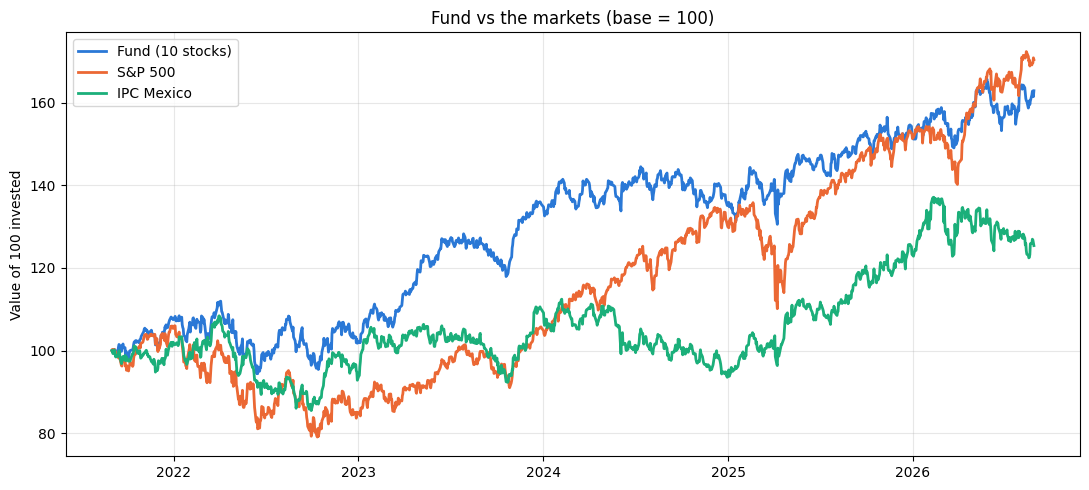

In [23]:
# 1. The fund against the two markets
plt.figure(figsize=(11, 5))

plt.plot(fondo_index.index, fondo_index / fondo_index.iloc[0] * 100, color=blue, linewidth=2, label="Fund (10 stocks)")

sp_index = (1 + sp500_return).cumprod()
ipc_index = (1 + ipc_return).cumprod()
plt.plot(sp_index.index, sp_index / sp_index.iloc[0] * 100, color=orange, linewidth=2, label="S&P 500")
plt.plot(ipc_index.index, ipc_index / ipc_index.iloc[0] * 100, color=green, linewidth=2, label="IPC Mexico")

plt.title("Fund vs the markets (base = 100)")
plt.ylabel("Value of 100 invested")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

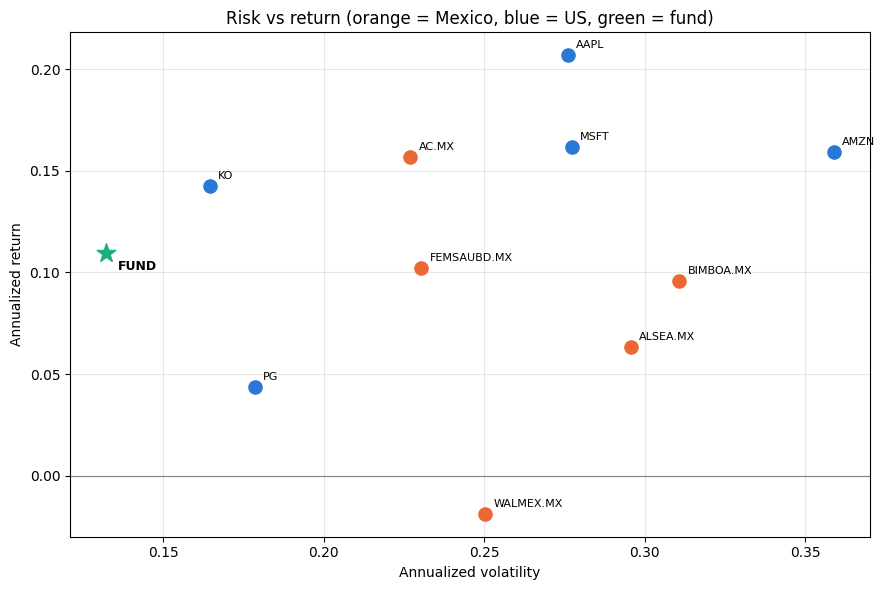

In [24]:
# 2. Risk against return, stock by stock
plt.figure(figsize=(9, 6))

for ticker in tickers:
    x = risk_metrics.loc[ticker, "Ann. Volatility"]
    y = risk_metrics.loc[ticker, "Ann. Return"]
    color = orange if ticker in tickers_mx else blue
    plt.scatter(x, y, s=90, color=color, zorder=3)
    plt.annotate(ticker, (x, y), xytext=(6, 5), textcoords="offset points", fontsize=8)

plt.scatter(fondo_annual_vol, fondo_annual_return, s=200, color=green, marker="*", zorder=4)
plt.annotate("FUND", (fondo_annual_vol, fondo_annual_return), xytext=(8, -12),
             textcoords="offset points", fontsize=9, fontweight="bold")

plt.axhline(0, color="gray", linewidth=0.8)
plt.title("Risk vs return (orange = Mexico, blue = US, green = fund)")
plt.xlabel("Annualized volatility")
plt.ylabel("Annualized return")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

The fund is better in every stock, which means less risk.

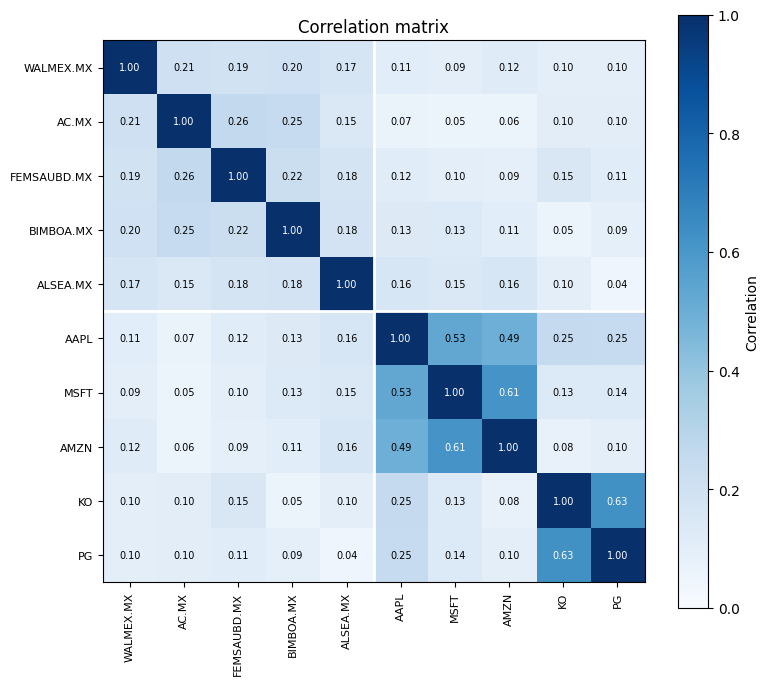

In [25]:
# 3. Correlation between the 10 stocks
plt.figure(figsize=(8, 7))
plt.imshow(correlation, cmap="Blues", vmin=0, vmax=1)
plt.colorbar(label="Correlation")

plt.xticks(range(len(tickers)), tickers, rotation=90, fontsize=8)
plt.yticks(range(len(tickers)), tickers, fontsize=8)

for i in range(len(tickers)):
    for j in range(len(tickers)):
        plt.text(j, i, f"{correlation.iloc[i, j]:.2f}", ha="center", va="center", fontsize=7,
                 color="white" if correlation.iloc[i, j] > 0.6 else "black")

# Line separating the Mexican stocks from the US ones
plt.axhline(4.5, color="white", linewidth=2)
plt.axvline(4.5, color="white", linewidth=2)

plt.title("Correlation matrix")
plt.tight_layout()
plt.show()

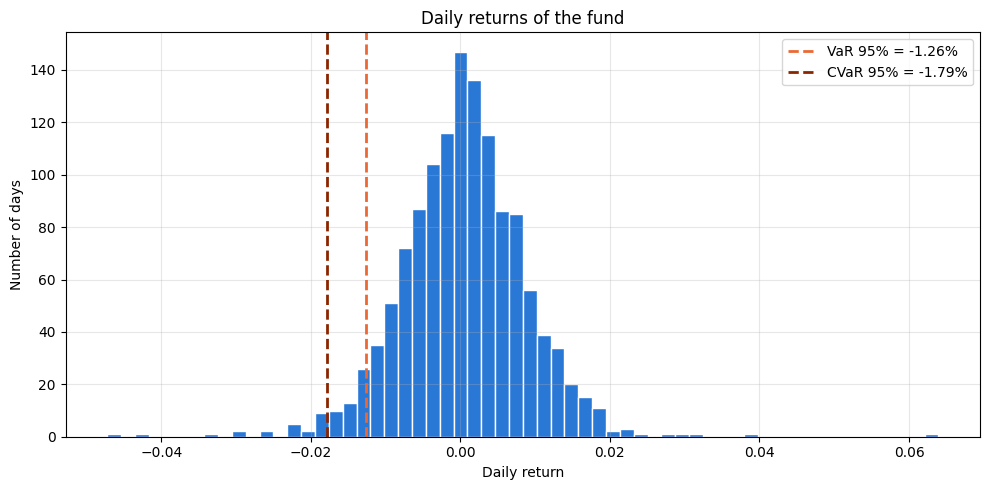

In [26]:
# 4. Distribution of the daily returns of the fund, with the VaR and the CVaR
plt.figure(figsize=(10, 5))
plt.hist(fondo_return, bins=60, color=blue, edgecolor="white")

plt.axvline(fondo_var, color=orange, linestyle="--", linewidth=2, label=f"VaR 95% = {fondo_var:.2%}")
plt.axvline(fondo_cvar, color="#8b2500", linestyle="--", linewidth=2, label=f"CVaR 95% = {fondo_cvar:.2%}")

plt.title("Daily returns of the fund")
plt.xlabel("Daily return")
plt.ylabel("Number of days")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

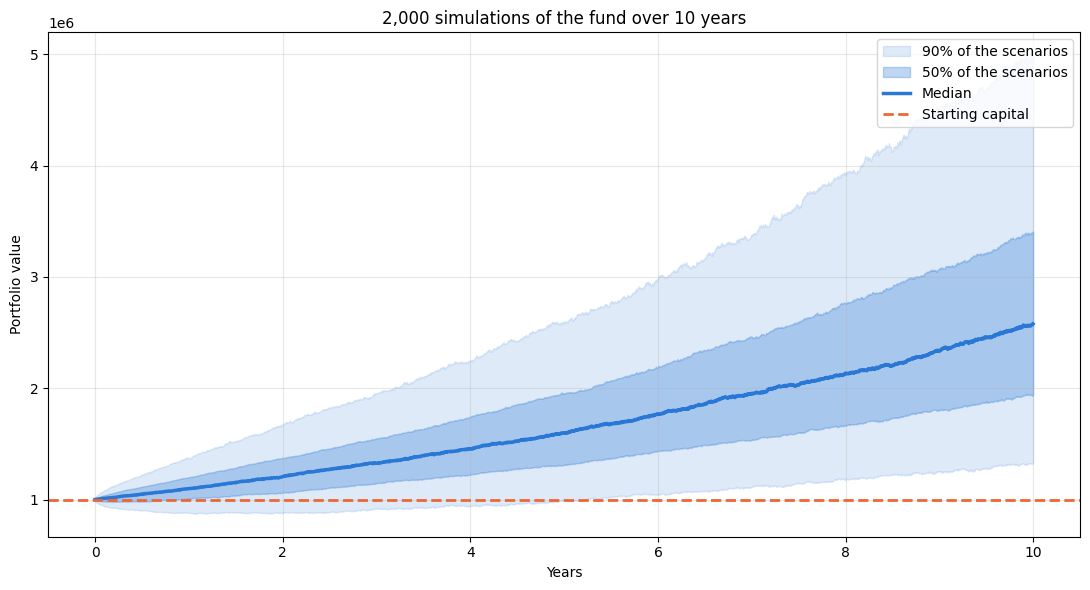

In [27]:
# 5. The Monte Carlo simulation
plt.figure(figsize=(11, 6))

years_axis = np.arange(days) / 252

plt.fill_between(years_axis, np.percentile(paths, 5, axis=1), np.percentile(paths, 95, axis=1),
                 color=blue, alpha=0.15, label="90% of the scenarios")
plt.fill_between(years_axis, np.percentile(paths, 25, axis=1), np.percentile(paths, 75, axis=1),
                 color=blue, alpha=0.3, label="50% of the scenarios")
plt.plot(years_axis, np.percentile(paths, 50, axis=1), color=blue, linewidth=2.5, label="Median")
plt.axhline(initial_capital, color=orange, linestyle="--", linewidth=2, label="Starting capital")

plt.title(f"{n_simulations:,} simulations of the fund over {years} years")
plt.xlabel("Years")
plt.ylabel("Portfolio value")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

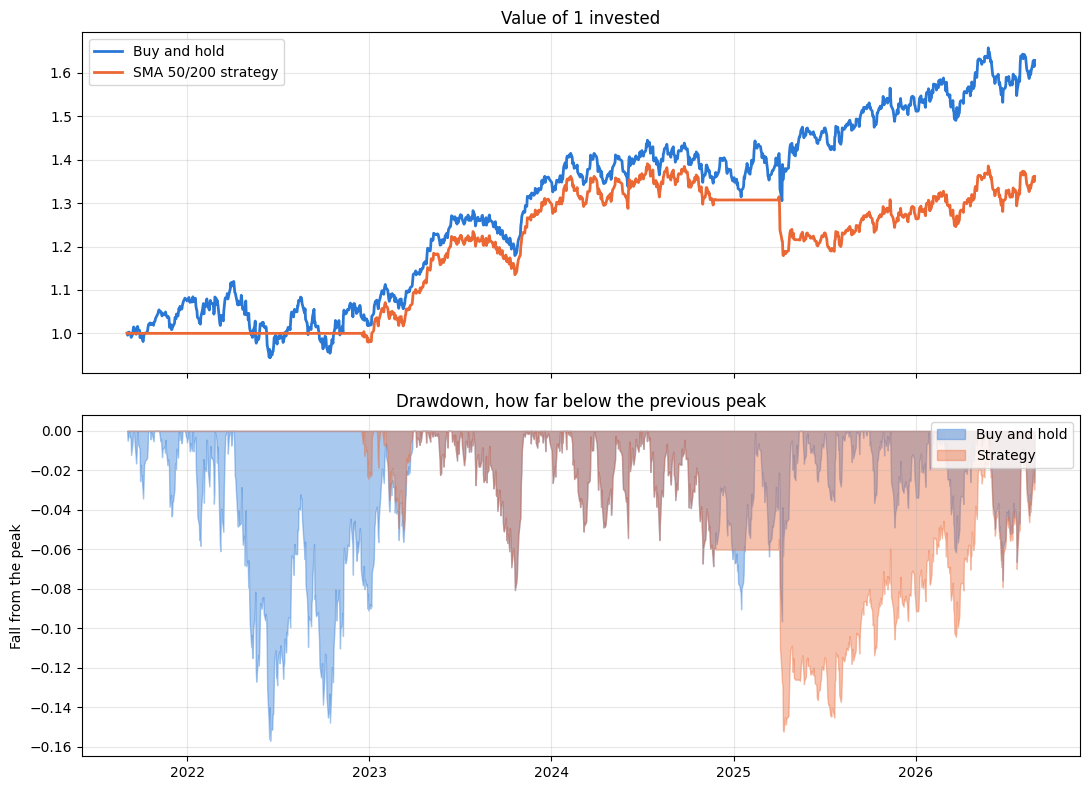

In [28]:
# 6. Backtest: the strategy against buying and holding
fig, axes = plt.subplots(2, 1, figsize=(11, 8), sharex=True)

axes[0].plot(backtest.index, backtest["buy_and_hold_value"], color=blue, linewidth=2, label="Buy and hold")
axes[0].plot(backtest.index, backtest["strategy_value"], color=orange, linewidth=2, label="SMA 50/200 strategy")
axes[0].set_title("Value of 1 invested")
axes[0].legend()
axes[0].grid(alpha=0.3)

dd_bh = backtest["buy_and_hold_value"] / backtest["buy_and_hold_value"].cummax() - 1
dd_st = backtest["strategy_value"] / backtest["strategy_value"].cummax() - 1

axes[1].fill_between(backtest.index, dd_bh, 0, color=blue, alpha=0.4, label="Buy and hold")
axes[1].fill_between(backtest.index, dd_st, 0, color=orange, alpha=0.4, label="Strategy")
axes[1].set_title("Drawdown, how far below the previous peak")
axes[1].set_ylabel("Fall from the peak")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

It is not enough for the strategy to end higher.

## 7. Export to Excel

In [29]:
with pd.ExcelWriter("capital_analyst_metrics.xlsx") as writer:
    risk_metrics.to_excel(writer, sheet_name="Risk Metrics")
    correlation.to_excel(writer, sheet_name="Correlation")
    comparison.to_excel(writer, sheet_name="Model Comparison")
    comparison_bt.to_excel(writer, sheet_name="Backtest")
    orders.to_excel(writer, sheet_name="Orders", index=False)

    monte_carlo_table = pd.DataFrame({
        "Scenario": ["Worst 5%", "Percentile 25", "Median", "Percentile 75", "Best 5%"],
        "Value in 10 years": [p5, p25, p50, p75, p95],
    })
    monte_carlo_table.to_excel(writer, sheet_name="Monte Carlo", index=False)

print("Saved capital_analyst_metrics.xlsx")

Saved capital_analyst_metrics.xlsx


## 8. Summary of Results

 Prints everything together.

In [30]:
print("=" * 62)
print("[8] SUMMARY OF RESULTS")
print("=" * 62)
print(f"Period: {fondo.index[0].date()} to {fondo.index[-1].date()}   ({len(fondo)} days)")
print()

print("--- 1. UNIVERSE ---")
print(f"Correlation inside Mexico:   {avg_mx:.3f}")
print(f"Correlation inside the US:   {avg_us:.3f}")
print(f"Correlation between markets: {avg_between:.3f}")
print(f"Average volatility of the stocks separately: {average_volatility:.2%}")
print(f"Volatility of the portfolio:                 {portfolio_volatility:.2%}")
print(f"Reduction from diversifying:                 {reduction:.2%}")
print()

print("--- 2. RISK METRICS OF THE FUND ---")
print(f"Annualized return: {fondo_annual_return:.2%}")
print(f"Annualized vol:    {fondo_annual_vol:.2%}")
print(f"Beta:              {fondo_beta:.3f}")
print(f"Sharpe:            {fondo_sharpe:.3f}")
print(f"VaR 95% hist:      {fondo_var:.2%}")
print(f"VaR 95% normal:    {fondo_var_normal:.2%}")
print(f"CVaR 95%:          {fondo_cvar:.2%}")
print(f"Max drawdown:      {fondo_max_drawdown:.2%}")
print(f"Risk free rate:    {risk_free:.2%}")
print()
print("Per stock:")
print(risk_metrics[["Ann. Return", "Ann. Volatility", "Beta", "Sharpe", "Max Drawdown"]].round(4))
print()

print("--- 3. MODELS ---")
print(comparison.round(4))
print()

print("--- 4. MONTE CARLO (10 years, $1,000,000) ---")
print(f"Worst 5%:      ${p5:,.0f}")
print(f"Percentile 25: ${p25:,.0f}")
print(f"Median:        ${p50:,.0f}")
print(f"Percentile 75: ${p75:,.0f}")
print(f"Best 5%:       ${p95:,.0f}")
print(f"Probability of losing money: {(final_values < initial_capital).mean():.1%}")
print(f"Probability of doubling:     {(final_values > 2 * initial_capital).mean():.1%}")
print()

print("--- 4.2 BACKTEST ---")
print(comparison_bt.round(4))
print(f"Number of trades: {int(trades.sum())}")
print()

print("--- 5. CURRENT SIGNAL ---")
print("Signal:", "INVESTED" if trend_is_up else "IN CASH")
print(f"Orders generated: {len(orders)}")
print()
print("=" * 62)

[8] SUMMARY OF RESULTS
Period: 2021-08-31 to 2026-08-28   (1293 days)

--- 1. UNIVERSE ---
Correlation inside Mexico:   0.200
Correlation inside the US:   0.321
Correlation between markets: 0.104
Average volatility of the stocks separately: 25.69%
Volatility of the portfolio:                 13.23%
Reduction from diversifying:                 48.52%

--- 2. RISK METRICS OF THE FUND ---
Annualized return: 10.94%
Annualized vol:    13.23%
Beta:              0.796
Sharpe:            0.543
VaR 95% hist:      -1.26%
VaR 95% normal:    -1.33%
CVaR 95%:          -1.79%
Max drawdown:      -15.69%
Risk free rate:    3.76%

Per stock:
             Ann. Return  Ann. Volatility    Beta  Sharpe  Max Drawdown
Stock                                                                  
WALMEX.MX        -0.0187           0.2502  0.8321 -0.2250       -0.3602
AC.MX             0.1570           0.2270  0.6217  0.5258       -0.1710
FEMSAUBD.MX       0.1020           0.2304  0.7199  0.2795       -0.3160
BIMBOA.